# TP5 AA1 Clasificación

**German Piasco**

# Seleccion del Dataset

In [1]:
import pandas as pd

columnas = [
    "age", "workclass", "fnlwgt", "education",
    "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain",
    "capital_loss", "hours_per_week", "native_country",
    "income"
]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(
    url,
    names=columnas,
    sep=", ",
    engine="python"
)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Mostramos el Dataset

In [2]:
print(df.shape)
df.info()

(32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Detectamos Valores Nulos

In [3]:
import numpy as np

df = df.replace("?", np.nan)
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


# Describimos variables numericas y categoricas

In [4]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.describe(include='object')
df['income'].value_counts(normalize=True)

,proportion
income,
<=50K,0.75919
>50K,0.24081


# Visualizaciones

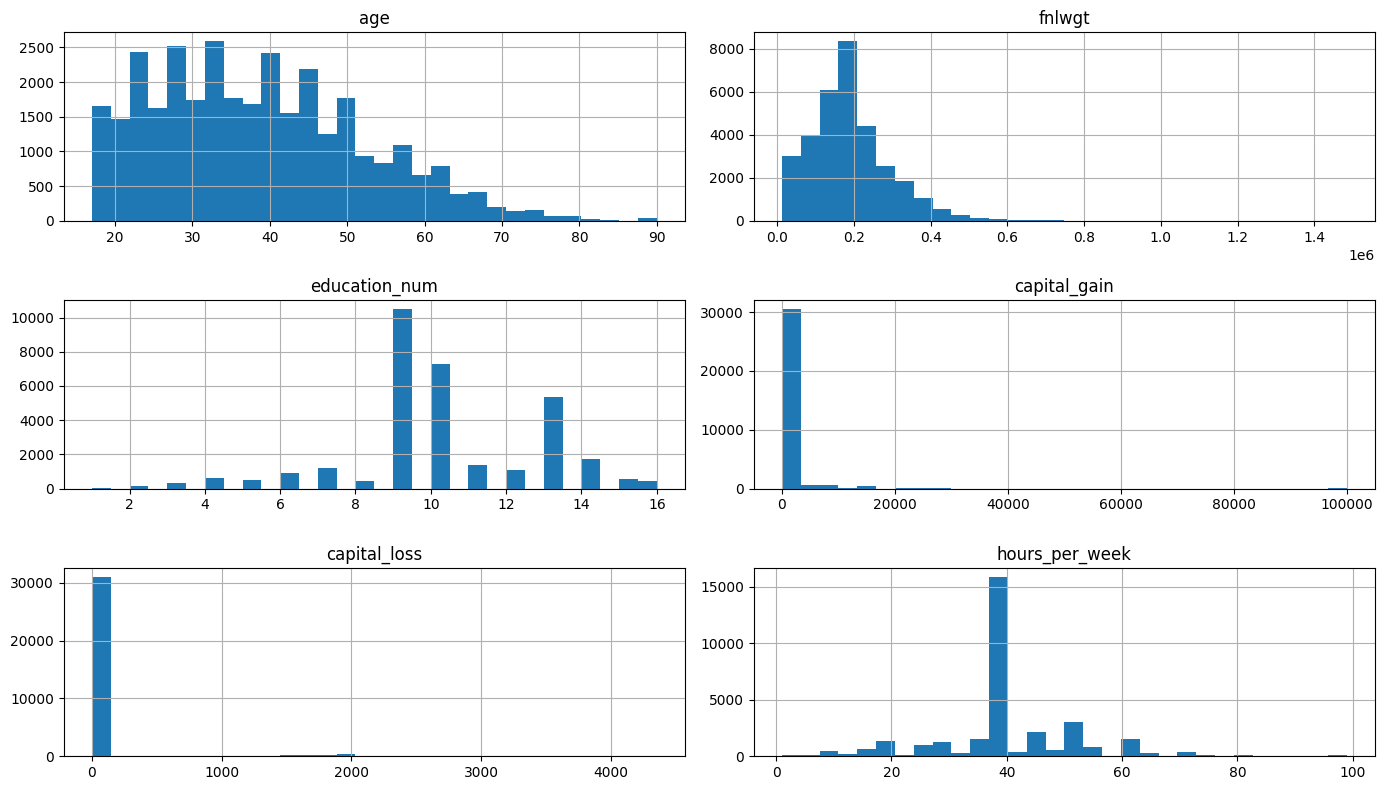

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

df[num_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

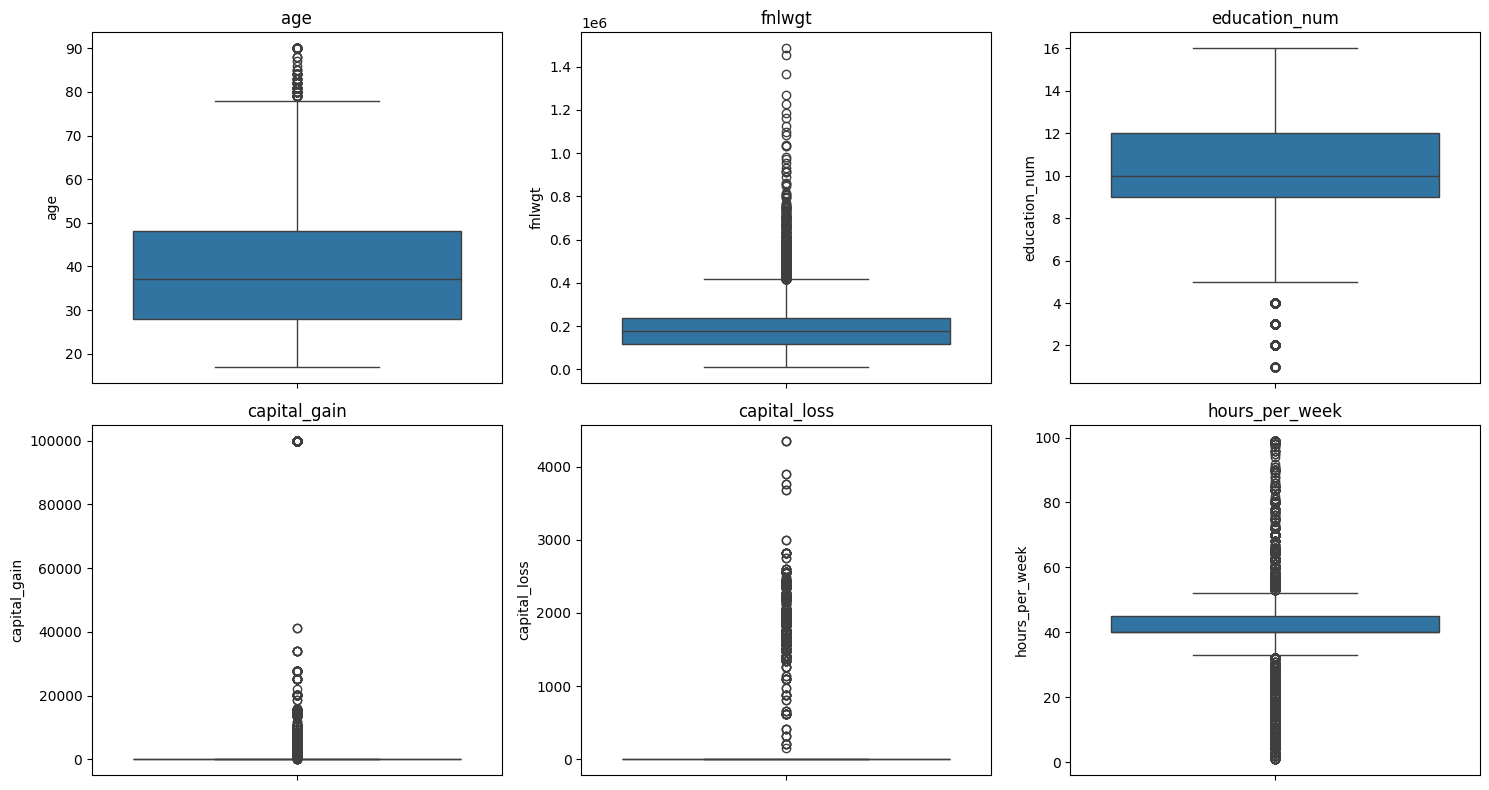

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Relación entre features y target

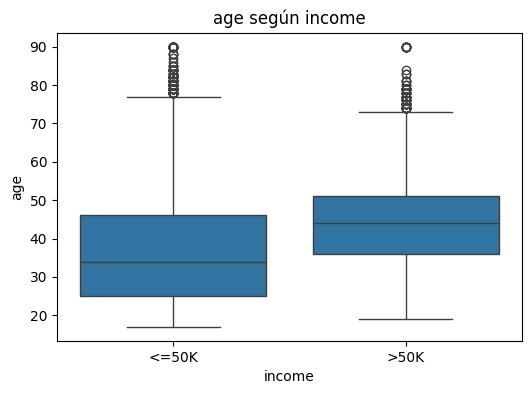

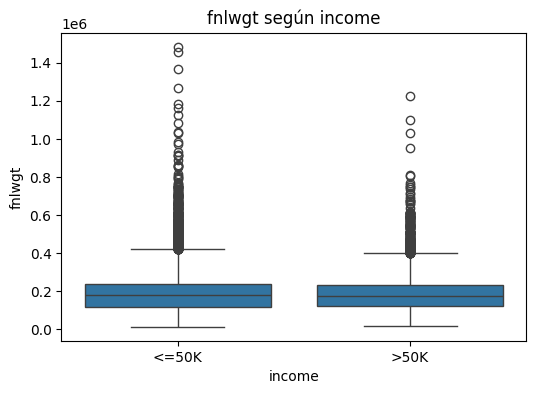

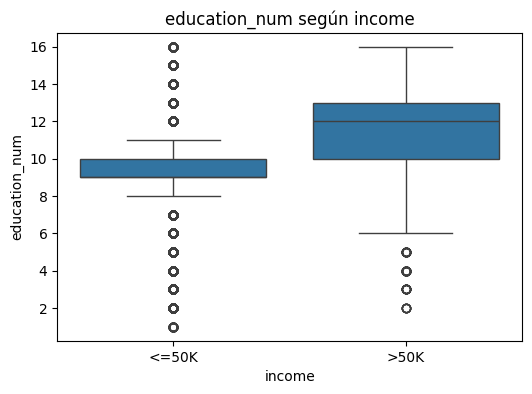

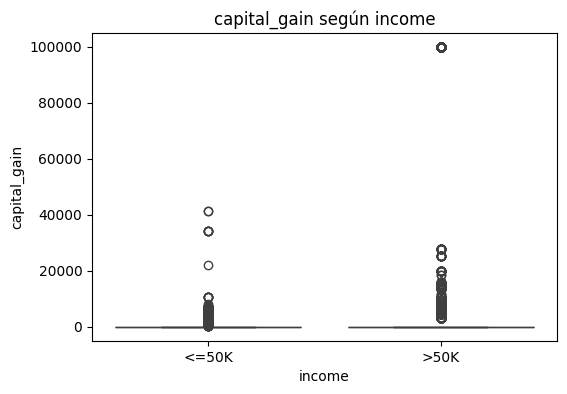

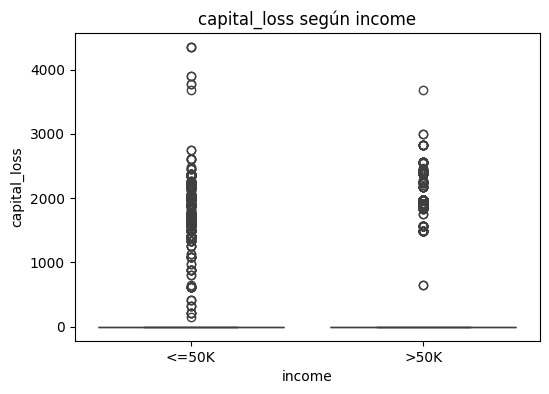

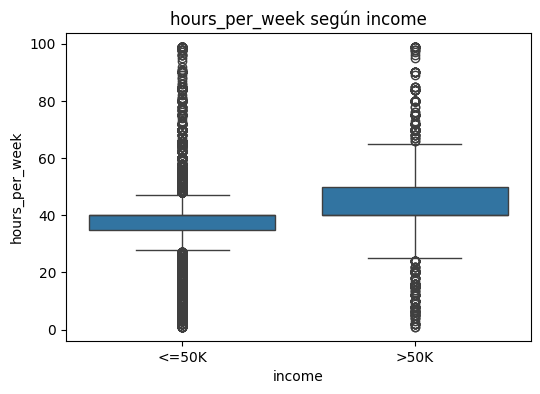

In [8]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='income', y=col, data=df)
    plt.title(f'{col} según income')
    plt.show()

# Relación entre variables

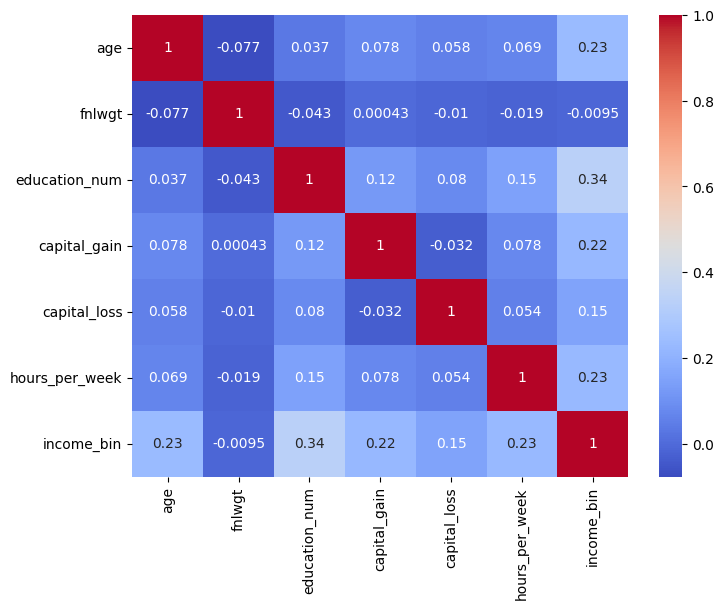

In [9]:
df['income_bin'] = df['income'].str.strip().map({'<=50K': 0, '>50K': 1})

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['income_bin']].corr(), annot=True, cmap='coolwarm')
plt.show()

# Limpiamos el dataset

In [10]:
# Limpiamos espacios en columnas de tipo texto
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    df[col] = df[col].str.strip()

# Eliminamos Datos Nulos

In [11]:
print("Filas antes:", df.shape[0])
df = df.dropna()
print("Filas después:", df.shape[0])

Filas antes: 32561
Filas después: 30162


# Eliminamos columnas que no son importantes y podrian entorpecer el modelo

In [12]:
df = df.drop(columns=['fnlwgt'])
df = df.drop(columns=['education'])

# Pasamos a numeros las variables categorias

In [13]:
cat_cols = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Target Binario

In [14]:
df_encoded['income'] = df_encoded['income'].map({'<=50K': 0, '>50K': 1})

In [15]:
df = df.drop(columns=['income_bin'])

# Escalamos variables numericas

In [16]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Características del dataset

In [17]:
print("Cantidad de instancias:", df_encoded.shape[0])
print("Cantidad de variables (features):", df_encoded.shape[1] - 1)
print("Tipo de problema: Clasificación binaria")
print(df_encoded['income'].value_counts(normalize=True))

Cantidad de instancias: 30162
Cantidad de variables (features): 81
Tipo de problema: Clasificación binaria
income
0    0.751078
1    0.248922
Name: proportion, dtype: float64


# División train/test

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reconstruimos sin escalar todavía
df_clean = df.copy()
df_clean['income'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

X = df_clean.drop(columns=['income'])
y = df_clean['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalamos numéricas: fit solo con train
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (24129, 80) Test: (6033, 80)


In [19]:
print(X.columns.tolist())

['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital_status_Married-AF-spouse', 'marital_status_Married-civ-spouse', 'marital_status_Married-spouse-absent', 'marital_status_Never-married', 'marital_status_Separated', 'marital_status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 's

# Entrenamiento y evaluación

In [20]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

# Generar predicciones

In [21]:
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# Métricas de evaluación

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== TRAIN ===")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1-score:", f1_score(y_train, y_train_pred))

print("\n=== TEST ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))

=== TRAIN ===
Accuracy: 0.8493928467818808
Precision: 0.7392093586123437
Recall: 0.6102231102231103
F1-score: 0.6685516234950748

=== TEST ===
Accuracy: 0.8458478368970661
Precision: 0.7295345104333868
Recall: 0.6051930758988016
F1-score: 0.6615720524017468


In [23]:
from sklearn.metrics import classification_report

print("=== TRAIN ===")
print(classification_report(y_train, y_train_pred, target_names=['<=50K', '>50K']))

print("=== TEST ===")
print(classification_report(y_test, y_test_pred, target_names=['<=50K', '>50K']))

=== TRAIN ===
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90     18123
        >50K       0.74      0.61      0.67      6006

    accuracy                           0.85     24129
   macro avg       0.81      0.77      0.79     24129
weighted avg       0.84      0.85      0.84     24129

=== TEST ===
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4531
        >50K       0.73      0.61      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.80      0.77      0.78      6033
weighted avg       0.84      0.85      0.84      6033



# Matriz de confusión

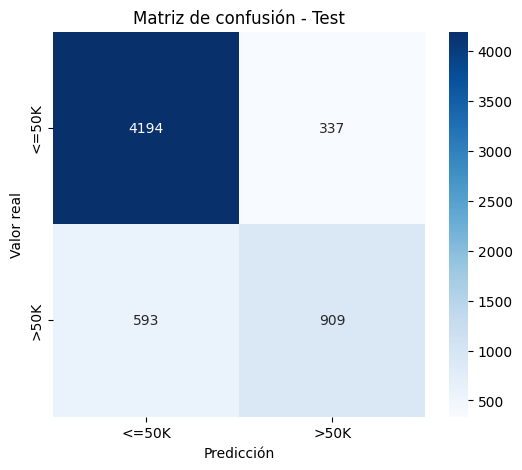

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Test')
plt.show()

# Aplicamos el modelo KNN

# Entrenamos el modelo nuevamente

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()  # parámetros por defecto (k=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
y_train_pred_knn = knn.predict(X_train)
y_test_pred_knn = knn.predict(X_test)

# Evaluamos su desempeño

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== TRAIN (kNN) ===")
print(classification_report(y_train, y_train_pred_knn, target_names=['<=50K', '>50K']))

print("=== TEST (kNN) ===")
print(classification_report(y_test, y_test_pred_knn, target_names=['<=50K', '>50K']))

=== TRAIN (kNN) ===
              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.92     18123
        >50K       0.79      0.71      0.75      6006

    accuracy                           0.88     24129
   macro avg       0.85      0.82      0.84     24129
weighted avg       0.88      0.88      0.88     24129

=== TEST (kNN) ===
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.89      4531
        >50K       0.69      0.61      0.65      1502

    accuracy                           0.84      6033
   macro avg       0.78      0.76      0.77      6033
weighted avg       0.83      0.84      0.83      6033



# Matriz de confusion

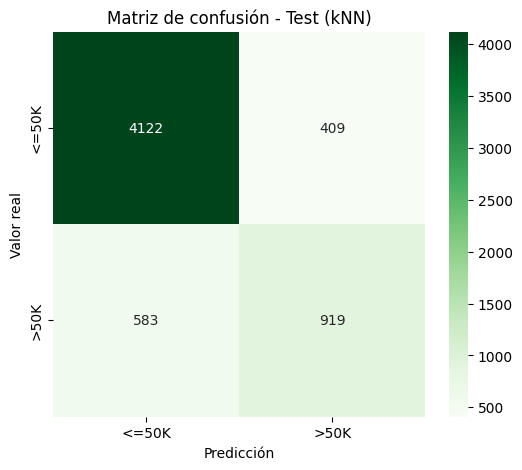

In [28]:
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Test (kNN)')
plt.show()

# Aplicamos hiperparametros

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]

train_acc = []
test_acc = []
test_f1 = []

for k in k_values:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    train_acc.append(accuracy_score(y_train, pred_train))
    test_acc.append(accuracy_score(y_test, pred_test))
    test_f1.append(f1_score(y_test, pred_test))  # f1 de la clase 1 (>50K) por defecto

resultados = pd.DataFrame({
    'k': k_values,
    'train_accuracy': train_acc,
    'test_accuracy': test_acc,
    'test_f1_(>50K)': test_f1
})
print(resultados)

    k  train_accuracy  test_accuracy  test_f1_(>50K)
0   1        0.972315       0.801425        0.602258
1   3        0.899581       0.827283        0.637691
2   5        0.880932       0.835571        0.649470
3   7        0.874176       0.836731        0.651080
4   9        0.870902       0.839218        0.657244
5  11        0.866634       0.839052        0.656526
6  15        0.861536       0.841207        0.660524
7  21        0.858552       0.839881        0.656472
8  31        0.854200       0.840046        0.659852
9  51        0.851548       0.842035        0.660733


# Visualizamos los resultados

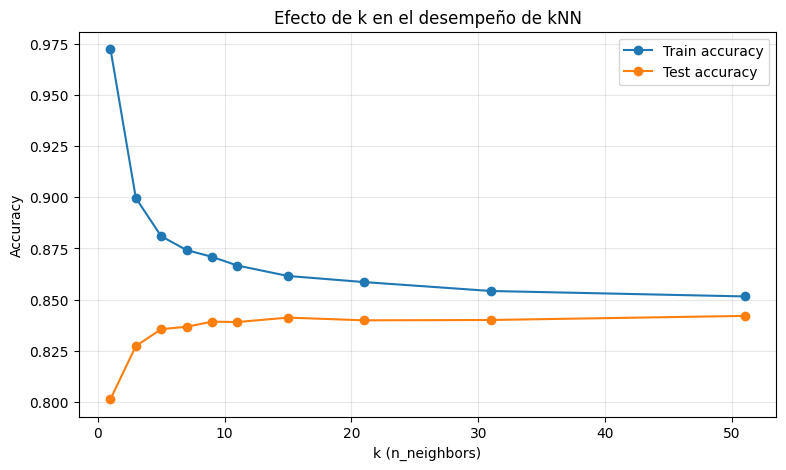

In [30]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, train_acc, marker='o', label='Train accuracy')
plt.plot(k_values, test_acc, marker='o', label='Test accuracy')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('Efecto de k en el desempeño de kNN')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Elegimos el mejor K

In [31]:
mejor_k = resultados.loc[resultados['test_accuracy'].idxmax(), 'k']
print(f"Mejor k según test accuracy: {mejor_k}")

Mejor k según test accuracy: 51


In [32]:
mejor_k_f1 = resultados.loc[resultados['test_f1_(>50K)'].idxmax(), 'k']
print(f"Mejor k según F1 de la clase >50K: {mejor_k_f1}")

Mejor k según F1 de la clase >50K: 51


# Entrenamos el modelo con el mejor K

In [33]:
knn_final = KNeighborsClassifier(n_neighbors=mejor_k)
knn_final.fit(X_train, y_train)

pred_test_final = knn_final.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, pred_test_final, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4531
        >50K       0.71      0.62      0.66      1502

    accuracy                           0.84      6033
   macro avg       0.79      0.77      0.78      6033
weighted avg       0.84      0.84      0.84      6033



# Evaluamos el modelo

In [34]:
knn_final = KNeighborsClassifier(n_neighbors=51)
knn_final.fit(X_train, y_train)

pred_train_final = knn_final.predict(X_train)
pred_test_final = knn_final.predict(X_test)

print("=== TRAIN (kNN, k=51) ===")
print(classification_report(y_train, pred_train_final, target_names=['<=50K', '>50K']))

print("=== TEST (kNN, k=51) ===")
print(classification_report(y_test, pred_test_final, target_names=['<=50K', '>50K']))

=== TRAIN (kNN, k=51) ===
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90     18123
        >50K       0.73      0.64      0.68      6006

    accuracy                           0.85     24129
   macro avg       0.81      0.78      0.79     24129
weighted avg       0.85      0.85      0.85     24129

=== TEST (kNN, k=51) ===
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4531
        >50K       0.71      0.62      0.66      1502

    accuracy                           0.84      6033
   macro avg       0.79      0.77      0.78      6033
weighted avg       0.84      0.84      0.84      6033



# Matriz de confusion

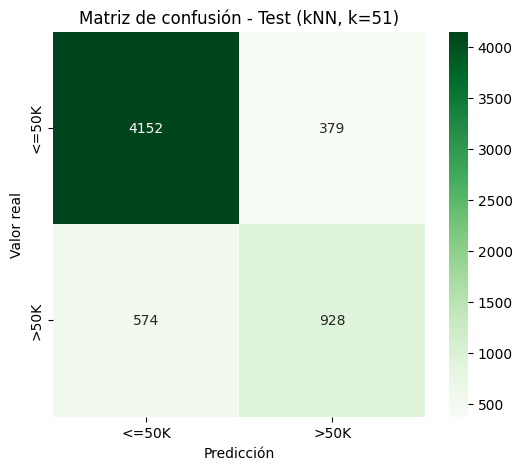

In [35]:
cm_final = confusion_matrix(y_test, pred_test_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión - Test (kNN, k=51)')
plt.show()

# **Conclusiones:**

En este trabajo analizamos el dataset Adult/Census Income (~30.000 instancias, 14 variables) para predecir si una persona gana más o menos de $50K anuales. Después de limpiar y preprocesar los datos, entrenamos y comparamos regresión logística y kNN. La regresión logística tuvo el mejor desempeño (accuracy 0.85) y generalizó muy bien, sin diferencia entre train y test. kNN con k=5 por defecto rindió un poco menos (0.84) y mostró overfitting, pero al tunear el hiperparámetro k probando varios valores, encontramos que k=51 reducía bastante esa brecha y lograba un F1 casi igual al de la regresión logística, mostrando lo importante que es ajustar los hiperparámetros en vez de dejar los valores por defecto. En los tres casos se repitió el mismo problema: el recall de la clase >50K fue bastante más bajo que el de la clase mayoritaria, reflejo del desbalance del dataset (75%/25%) más que de los modelos en sí. Como mejora futura, se podrían aplicar técnicas de balanceo de clases como SMOTE o class_weight='balanced' para mejorar específicamente la detección de la clase minoritaria.